# Peptide Levenshtein Distance Analysis

Goal: compute pairwise Levenshtein (edit) distances between **unique peptides** in the combined BEAM dataset and ask:

> **Are peptides from the same pathogen more similar (lower edit distance) to each other than peptides from different pathogens?**

Notes on the data:
- The pathogen label lives in the `peptide_organism` column (`EBV`, `Influenza`, `CMV`).
- Most unique peptides are *randomized / in-silico negatives* and have **no** pathogen label — they are included in the full distance matrix but excluded from the within-vs-between-pathogen comparison.
- Only **12** peptides carry a pathogen label (CMV: 2, EBV: 6, Influenza: 4), so the same-vs-different test is run on a small set; we use a permutation test rather than relying on asymptotic assumptions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import Levenshtein
from scipy.spatial.distance import squareform
from scipy.cluster import hierarchy
from sklearn.manifold import MDS
from itertools import combinations

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

CSV = "combined_BEAM_with_inSilicoNegatives_w_HIV_CMV_HPV.csv"

## 1. Load data and extract unique peptides

In [2]:
df = pd.read_csv(CSV, low_memory=False)
print("rows:", len(df), "| columns:", df.shape[1])

# One row per unique peptide, carrying its pathogen label (if any).
# (Verified upstream: no peptide maps to more than one organism label.)
pep = (df[["peptide", "peptide_organism"]]
       .dropna(subset=["peptide"])
       .drop_duplicates("peptide")
       .reset_index(drop=True))
pep["length"] = pep["peptide"].str.len()
pep["labeled"] = pep["peptide_organism"].notna()

print("\nunique peptides:", len(pep))
print("\nlabeled peptides by organism:")
print(pep["peptide_organism"].value_counts(dropna=False))
print("\npeptide length distribution:")
print(pep["length"].value_counts().sort_index())

rows: 12260 | columns: 91

unique peptides: 668

labeled peptides by organism:
peptide_organism
NaN          656
EBV            6
Influenza      4
CMV            2
Name: count, dtype: int64

peptide length distribution:
length
8       1
9     617
10     46
11      4
Name: count, dtype: int64


In [3]:
# The labeled (pathogen-known) peptides we will test
labeled = pep[pep["labeled"]].sort_values("peptide_organism").reset_index(drop=True)
labeled

,peptide,peptide_organism,length,labeled
0,TPRVTGGGAM,CMV,10,True
1,NLVPMVATV,CMV,9,True
2,IVTDFSVIK,EBV,9,True
3,CLGGLLTMV,EBV,9,True
4,AVFDRKSDAK,EBV,10,True
5,ATIGTAMYK,EBV,9,True
6,RPPIFIRRL,EBV,9,True
7,GLCTLVAML,EBV,9,True
8,GILGFVFTL,Influenza,9,True
9,FMYSDFHFI,Influenza,9,True


## 2. Pairwise Levenshtein distance matrix (all unique peptides)

Levenshtein distance = minimum number of single-character insertions, deletions or substitutions to turn one peptide into another. Because peptides differ in length (8–11 aa here), edit distance is the natural metric (Hamming would not apply across lengths).

In [4]:
def levenshtein_matrix(seqs):
    """Symmetric n x n matrix of pairwise Levenshtein distances."""
    n = len(seqs)
    M = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(i + 1, n):
            d = Levenshtein.distance(seqs[i], seqs[j])
            M[i, j] = M[j, i] = d
    return M

all_seqs = pep["peptide"].tolist()
D_all = levenshtein_matrix(all_seqs)
print("full distance matrix:", D_all.shape)

# distribution of all pairwise distances
iu = np.triu_indices_from(D_all, k=1)
all_pairwise = D_all[iu]
print("pairwise distances: min=%d max=%d mean=%.2f" % (all_pairwise.min(), all_pairwise.max(), all_pairwise.mean()))

full distance matrix: (668, 668)
pairwise distances: min=4 max=11 mean=8.55


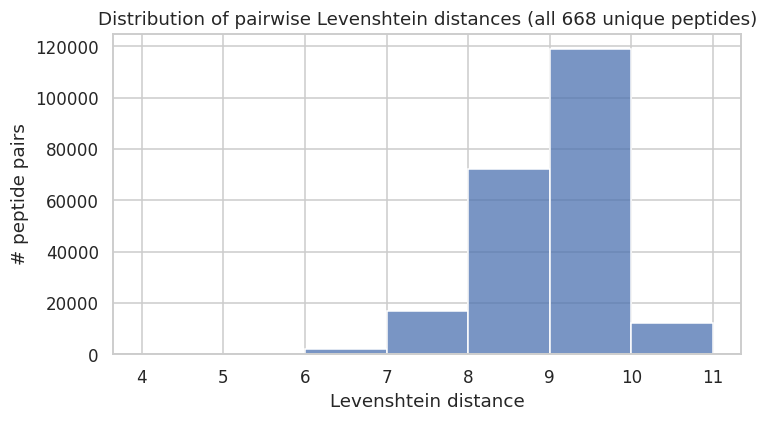

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(all_pairwise, binwidth=1, ax=ax)
ax.set(title="Distribution of pairwise Levenshtein distances (all %d unique peptides)" % len(pep),
       xlabel="Levenshtein distance", ylabel="# peptide pairs")
plt.tight_layout()
plt.show()

/nfs/users/nfs_d/dp31/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/nfs/users/nfs_d/dp31/.local/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/nfs/users/nfs_d/dp31/.local/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/nfs/users/nfs_d/dp31/.local/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


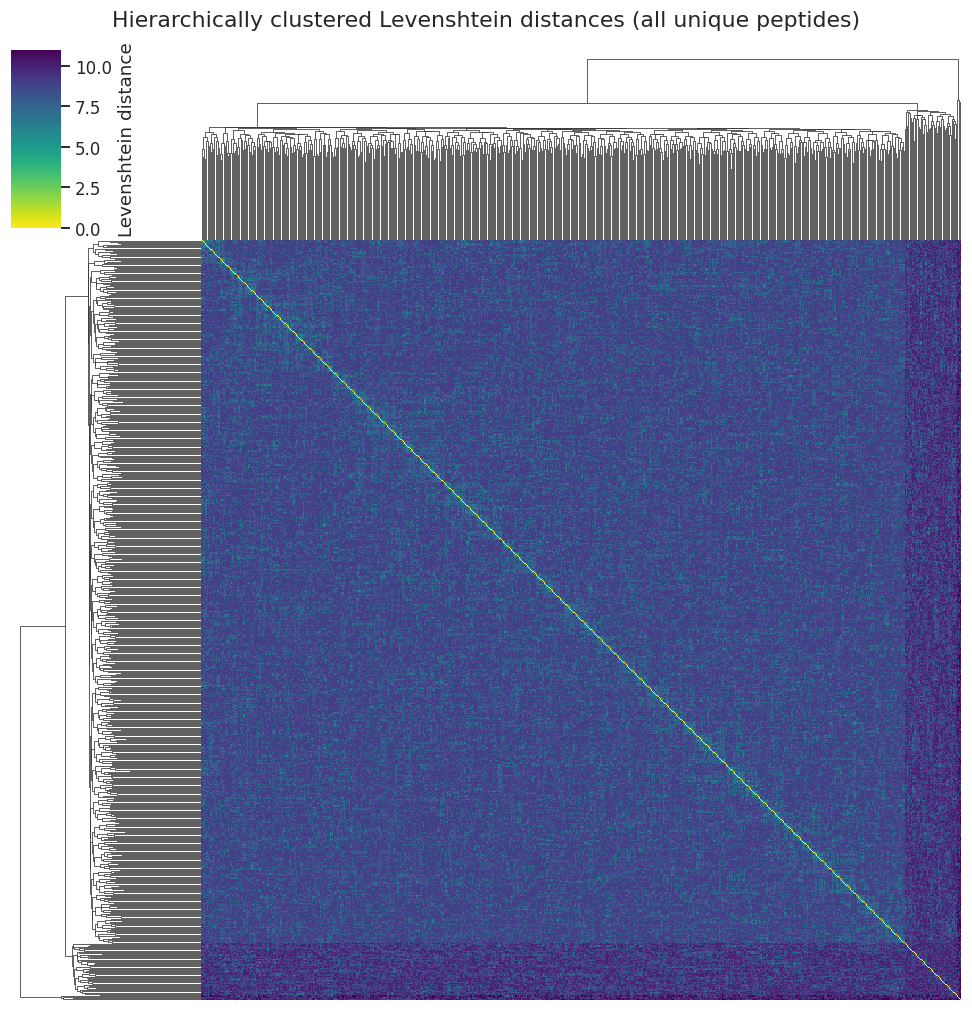

In [6]:
# Clustered heatmap of the full matrix (overview of global structure)
cg = sns.clustermap(
    D_all,
    method="average",
    cmap="viridis_r",
    figsize=(9, 9),
    xticklabels=False, yticklabels=False,
    cbar_kws={"label": "Levenshtein distance"},
)
cg.fig.suptitle("Hierarchically clustered Levenshtein distances (all unique peptides)", y=1.02)
plt.show()

## 3. Focus on labeled peptides: within- vs between-pathogen distances

/nfs/users/nfs_d/dp31/.local/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/nfs/users/nfs_d/dp31/.local/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


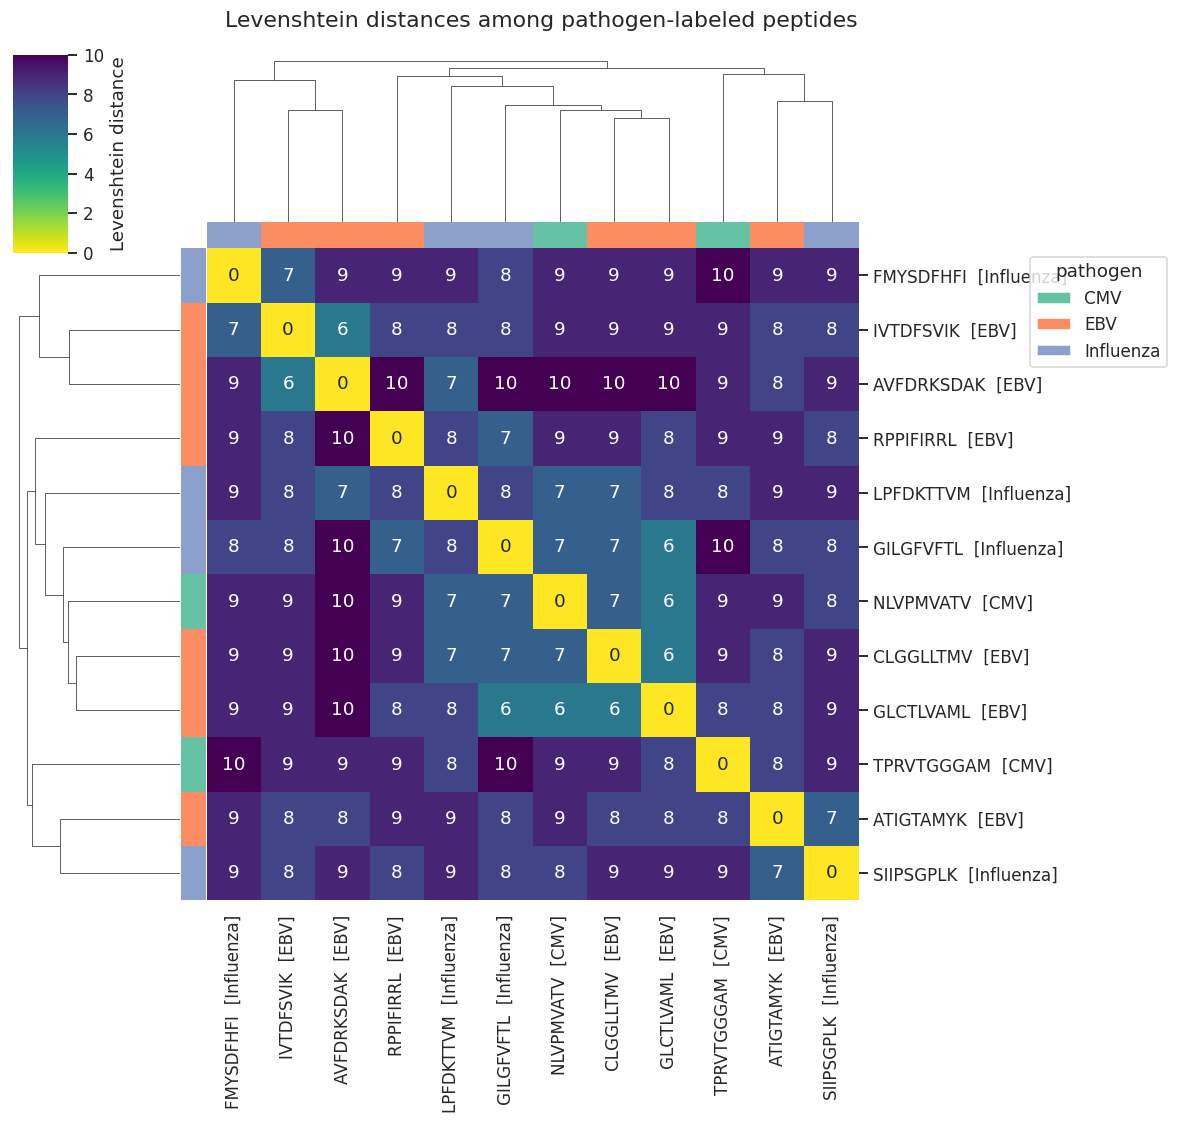

In [7]:
lab_seqs = labeled["peptide"].tolist()
lab_org = labeled["peptide_organism"].tolist()
D_lab = levenshtein_matrix(lab_seqs)

# Annotated heatmap of the 12 labeled peptides, grouped by organism
org_palette = dict(zip(sorted(set(lab_org)), sns.color_palette("Set2", len(set(lab_org)))))
row_colors = [org_palette[o] for o in lab_org]
labels = [f"{p}  [{o}]" for p, o in zip(lab_seqs, lab_org)]

D_lab_df = pd.DataFrame(D_lab, index=labels, columns=labels)
cg = sns.clustermap(D_lab_df, method="average", cmap="viridis_r",
                    row_colors=row_colors, col_colors=row_colors,
                    annot=True, fmt="d", figsize=(10, 10),
                    cbar_kws={"label": "Levenshtein distance"})
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=o) for o, c in org_palette.items()]
cg.ax_heatmap.legend(handles=handles, title="pathogen", bbox_to_anchor=(1.25, 1.0), loc="upper left")
cg.fig.suptitle("Levenshtein distances among pathogen-labeled peptides", y=1.02)
plt.show()

In [8]:
# Split labeled pairs into within-pathogen vs between-pathogen
records = []
for i, j in combinations(range(len(lab_seqs)), 2):
    same = lab_org[i] == lab_org[j]
    records.append({
        "pep_i": lab_seqs[i], "pep_j": lab_seqs[j],
        "org_i": lab_org[i], "org_j": lab_org[j],
        "distance": D_lab[i, j],
        "group": "within-pathogen" if same else "between-pathogen",
    })
pairs = pd.DataFrame(records)

print(pairs.groupby("group")["distance"].describe())
print("\nwithin-pathogen pairs: %d | between-pathogen pairs: %d"
      % ((pairs.group == "within-pathogen").sum(), (pairs.group == "between-pathogen").sum()))

                  count      mean       std  min   25%  50%  75%   max
group                                                                 
between-pathogen   44.0  8.295455  1.047245  6.0  7.75  8.5  9.0  10.0
within-pathogen    22.0  8.454545  1.056827  6.0  8.00  8.5  9.0  10.0

within-pathogen pairs: 22 | between-pathogen pairs: 44


/tmp/ipykernel_2116958/1330544864.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pairs, x="group", y="distance", ax=axes[0], palette="Set2", width=0.5)


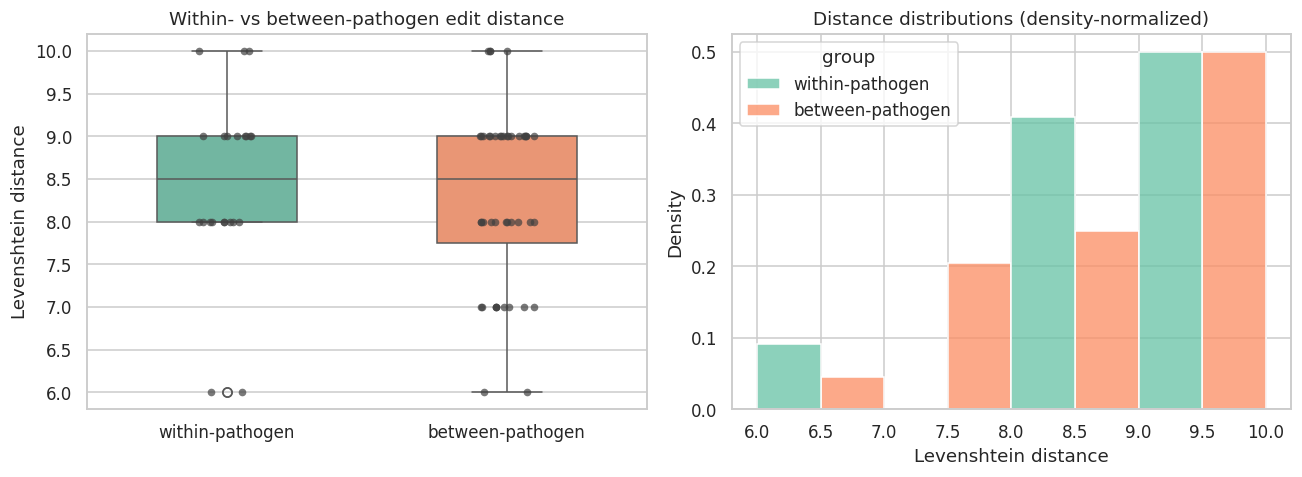

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=pairs, x="group", y="distance", ax=axes[0], palette="Set2", width=0.5)
sns.stripplot(data=pairs, x="group", y="distance", ax=axes[0], color=".25", size=5, alpha=0.7)
axes[0].set(title="Within- vs between-pathogen edit distance", xlabel="", ylabel="Levenshtein distance")

sns.histplot(data=pairs, x="distance", hue="group", multiple="dodge",
             binwidth=1, stat="density", common_norm=False, palette="Set2", ax=axes[1])
axes[1].set(title="Distance distributions (density-normalized)", xlabel="Levenshtein distance")
plt.tight_layout()
plt.show()

## 4. Is the difference significant?

With only 12 labeled peptides the pairwise distances are not independent (each peptide appears in many pairs), so a plain Mann-Whitney test understates the dependence. We therefore use a **label-permutation test**: shuffle the pathogen labels across peptides, recompute the mean within-pathogen distance, and compare to the observed value. This preserves the pairing structure under the null "pathogen membership is unrelated to sequence similarity".

In [10]:
from scipy.stats import mannwhitneyu

obs_within = pairs.loc[pairs.group == "within-pathogen", "distance"]
obs_between = pairs.loc[pairs.group == "between-pathogen", "distance"]
obs_diff = obs_within.mean() - obs_between.mean()   # negative => same-pathogen closer

u, p_mw = mannwhitneyu(obs_within, obs_between, alternative="less")
print("Observed mean within-pathogen distance : %.3f" % obs_within.mean())
print("Observed mean between-pathogen distance: %.3f" % obs_between.mean())
print("Difference (within - between)          : %.3f" % obs_diff)
print("\nMann-Whitney U (within < between), p = %.4g  [naive, ignores pair dependence]" % p_mw)

Observed mean within-pathogen distance : 8.455
Observed mean between-pathogen distance: 8.295
Difference (within - between)          : 0.159

Mann-Whitney U (within < between), p = 0.7209  [naive, ignores pair dependence]


Permutation test (20000 shuffles)
observed mean within-pathogen distance : 8.455
null mean (shuffled)                   : 8.346
one-sided p (within smaller than null) : 0.757


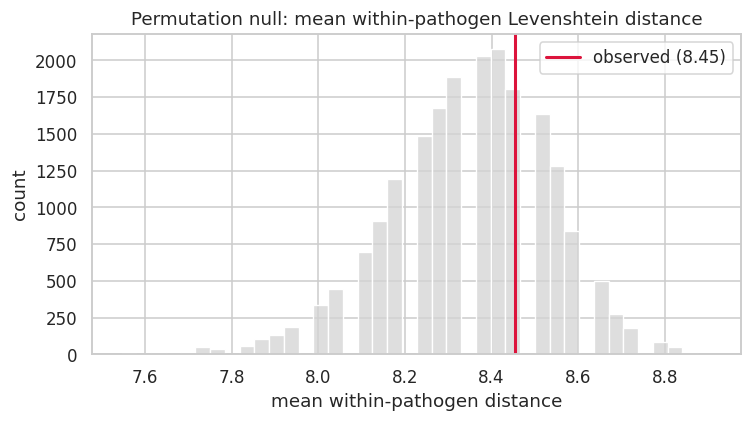

In [11]:
rng = np.random.default_rng(0)
N_PERM = 20000
orgs = np.array(lab_org)
iu_lab = np.triu_indices(len(lab_seqs), k=1)
dist_vec = D_lab[iu_lab]

def mean_within(labels):
    same = labels[iu_lab[0]] == labels[iu_lab[1]]
    return dist_vec[same].mean()

obs_stat = mean_within(orgs)
perm_stats = np.empty(N_PERM)
for k in range(N_PERM):
    perm_stats[k] = mean_within(rng.permutation(orgs))

# one-sided p: how often does shuffling give a within-distance as small as observed?
p_perm = (np.sum(perm_stats <= obs_stat) + 1) / (N_PERM + 1)
print("Permutation test (%d shuffles)" % N_PERM)
print("observed mean within-pathogen distance : %.3f" % obs_stat)
print("null mean (shuffled)                   : %.3f" % perm_stats.mean())
print("one-sided p (within smaller than null) : %.4g" % p_perm)

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(perm_stats, bins=40, ax=ax, color="lightgray")
ax.axvline(obs_stat, color="crimson", lw=2, label="observed (%.2f)" % obs_stat)
ax.set(title="Permutation null: mean within-pathogen Levenshtein distance",
       xlabel="mean within-pathogen distance", ylabel="count")
ax.legend()
plt.tight_layout()
plt.show()

## 5. 2D embedding of labeled peptides

Metric MDS on the labeled-peptide distance matrix — if same-pathogen peptides cluster, points of the same color should sit close together.

/nfs/users/nfs_d/dp31/.local/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


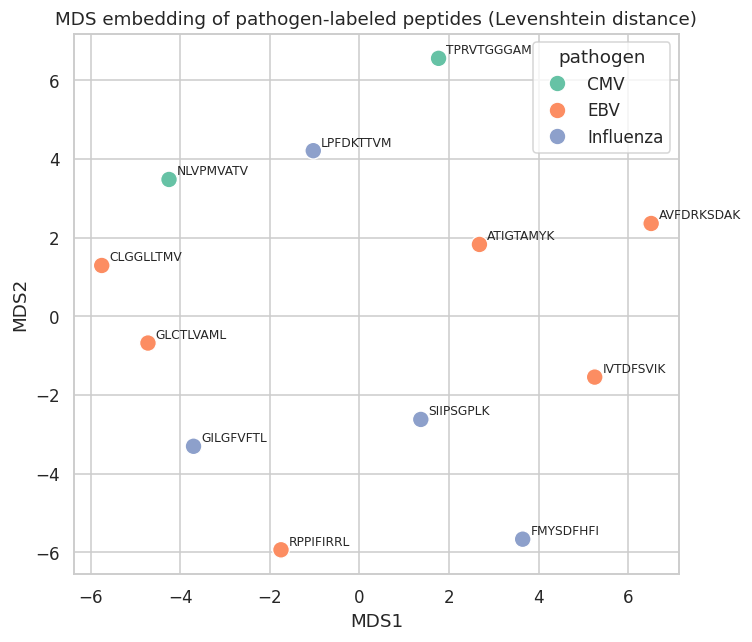

In [12]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=0, normalized_stress="auto")
xy = mds.fit_transform(D_lab)
emb = pd.DataFrame(xy, columns=["MDS1", "MDS2"])
emb["pathogen"] = lab_org
emb["peptide"] = lab_seqs

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=emb, x="MDS1", y="MDS2", hue="pathogen", palette="Set2", s=120, ax=ax)
for _, r in emb.iterrows():
    ax.annotate(r["peptide"], (r["MDS1"], r["MDS2"]), fontsize=8,
                xytext=(5, 3), textcoords="offset points")
ax.set_title("MDS embedding of pathogen-labeled peptides (Levenshtein distance)")
plt.tight_layout()
plt.show()

## 6. Per-pathogen summary

For each pathogen: mean distance among its own peptides vs. mean distance to peptides of other pathogens.

In [13]:
summary = []
for org in sorted(set(lab_org)):
    w = pairs[(pairs.group == "within-pathogen") & (pairs.org_i == org)]["distance"]
    b = pairs[(pairs.group == "between-pathogen") & ((pairs.org_i == org) | (pairs.org_j == org))]["distance"]
    summary.append({
        "pathogen": org,
        "n_peptides": (np.array(lab_org) == org).sum(),
        "n_within_pairs": len(w),
        "mean_within": round(w.mean(), 2) if len(w) else np.nan,
        "mean_between": round(b.mean(), 2),
    })
summary_df = pd.DataFrame(summary)
summary_df

,pathogen,n_peptides,n_within_pairs,mean_within,mean_between
0,CMV,2,1,9.0,8.50
1,EBV,6,15,8.4,8.25
2,Influenza,4,6,8.5,8.22


## 7. Conclusion

Read the printed permutation p-value and the boxplot/MDS above. Interpretation guide:

- **mean within-pathogen distance < mean between-pathogen distance** *and* small permutation p → same-pathogen peptides are measurably more similar by edit distance.
- If the two distributions overlap heavily and p is large → at the sequence (Levenshtein) level, pathogen origin does **not** strongly determine peptide similarity, which is biologically plausible: epitopes from the same pathogen come from different proteins and need not share sequence.

**Important caveat:** only 12 peptides carry a pathogen label (CMV: 2, EBV: 6, Influenza: 4), so statistical power is very low and CMV contributes a single within-pathogen pair. Treat this as exploratory. To strengthen it, add more pathogen-labeled epitopes (e.g. map the HIV/HPV peptides, or pull labels from IEDB).